In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols, mixedlm

import time
from datetime import date

# updated src file changes are loaded
%load_ext autoreload
%autoreload 2

# provides interactive "R studio-like" view of dataframes
from itables import init_notebook_mode, show
init_notebook_mode(all_interactive=True)

# ensures function files are visible: can use 'src.loading' for example
sys.path.append(os.path.abspath(".."))

In [2]:
from src.loading import load_data

# ------------------- Spatial Generalization 3.0 m/s
#df = load_data("../data/spatial_generalization/spatial_generalization_3m.parquet", keep_col='training_status')
# # drop every row from participant p007
#df = df[df['ppid'] != 'p007'].copy()

# ------------------- Spatial Generalization 2.0 m/s
df = load_data("../data/target_trial_spatial_generalization.parquet", keep_col='training_status')

df_full = df.copy()

In [5]:


# fix water_speed_binary if needed
from pandas.api.types import is_integer_dtype

if not is_integer_dtype(df_full['water_speed_binary']):

    print('water_speed_binary is acting strange: Implementing fix...')
    
    df_full['water_speed_binary2'] = (df_full['water_speed_m_s'] != 0.0).astype(int).copy()
    df_full['water_speed_binary'] = df_full['water_speed_binary2'].copy()
    
    # drops redundant col
    df_full.drop(columns=['water_speed_binary2'], inplace=True)
    

# add new variables
df_full['lateral_error_x'] = (df_full['min_pos_from_target_x'] - df_full['target_position_x']) 
df_full['depth_error_z'] = (df_full['min_pos_from_target_z'] - df_full['target_position_z']) 


# convert key columns to cm:
from src.convert_to_cm import convert_to_cm

df_labeled = convert_to_cm(df_full,
              cols=[
                    'min_pos_from_target_x',
                    'min_pos_from_target_z',
                    'target_position_x',
                    'target_position_z',
                    'lateral_error_x',
                    'depth_error_z'
                   ])

print('res:', df_labeled['target_position_x'].dtypes)

# label ppid by water speed
from src.label_water_speed_ppid import label_water_condtion_ppid
df_labeled = label_water_condtion_ppid(df_labeled, ppid_col='ppid', water_col='water_speed_m_s', selected_speeds=[-3.0,-2.0,0.0]).copy() 
# one-dimensional errors - in cm
#df_labeled['lateral_error_x_cm'] = (df_labeled['min_pos_from_target_x'] - df_labeled['target_position_x']) * 100 # convert to cm
#df_labeled['depth_error_z_cm'] = (df_labeled['min_pos_from_target_z'] - df_labeled['target_position_z']) * 100



# order targets

# adjust target label
target_mapping = {
    "p0.6": "U60",
    "p0.3": "U30",
    "neg0.3": "D30",
    "neg0.6": "D60"
}
df_labeled['target_x_label'] = df_labeled['target_x_label'].map(target_mapping).copy()

from src.features import order_targets
df_labeled['target_position_x'] = order_targets(df_labeled.copy())
df_labeled['target_x_label'] = order_targets(df_labeled.copy())




df_labeled['set_order'] = df_labeled['set_order'].replace({
    '1': 'AB',
    '2': 'BA'
}).copy()

# ensures PCA compatibility
df_labeled['water_speed_m_s'] = df_labeled['water_speed_m_s'].replace(0.0, 0.0001).copy()

# Converts the entire column to integers
df_labeled['water_speed_binary'] = df_labeled['water_speed_binary'].astype(int)


water_speed_binary is acting strange: Implementing fix...
res: float64
0       U30
1       D30
2       U60
3       D60
4       D30
       ... 
7324    U30
7325    U30
7326    D60
7327    U60
7328    D30
Name: target_x_label, Length: 7327, dtype: category
Categories (4, object): ['D60' < 'D30' < 'U30' < 'U60']
0       U30
1       D30
2       U60
3       D60
4       D30
       ... 
7324    U30
7325    U30
7326    D60
7327    U60
7328    D30
Name: target_x_label, Length: 7327, dtype: category
Categories (4, object): ['D60' < 'D30' < 'U30' < 'U60']


C:\Users\jacob\AppData\Local\Temp\ipykernel_7736\1116851301.py:62: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_labeled['set_order'] = df_labeled['set_order'].replace({


In [7]:
df_labeled

Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


In [9]:
### SPEED 2.0 Trial Schedule

In [7]:
from src.add_phases import label_phases, df_add_phases

assert (~df_labeled['experiment'].str.startswith('novel')).all(),  "Ensure you selected the correct data."

phases = label_phases(n_phases=10,
                      phase_names = ['familiarization',
                                   'baseline',
                                   'training_1',
                                   'washout_ST_1',
                                   'retention_ST_1',
                                    'washout_ST_2',
                                     'retention_ST_2',
                                   'washout_AT_1',
                                   'training_2',
                                    'washout_AT_2'])

df_labeled = df_add_phases(df_labeled, 
                           phase_array=phases,
                          trial_lo = np.array([1,21,53,278,282,286,290,294,310,374]),
                        trial_hi = np.array([20,52,277,281,285,289,293,309,373,385])
)

from src.plotting import plot_trial_schedule
#g = plot_trial_schedule(df_labeled, y_col='water_speed_binary', context='poster', font_scale=3)


from src.add_cycles import add_cycles
df_labeled = add_cycles(df_labeled,
                       n_trials=4,
                       grouping_vars=['ppid_full','target_x_label'],
                       ).copy()

df_labeled


C:\Users\jacob\water_current_MA\src\add_phases.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['phase_target_trial_num'] = df.groupby(['ppid_full', 'phase', 'target_x_label']).cumcount() + 1
C:\Users\jacob\water_current_MA\src\add_cycles.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby(grouping_vars).cumcount()
C:\Users\jacob\water_current_MA\src\add_cycles.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and sil

Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


In [ ]:
### SPEED 3.0 Trial Schedule

In [7]:
from src.add_phases import label_phases, df_add_phases

assert (df_labeled['experiment'].str.startswith('novel')).all(),  "Ensure you selected the correct data."

phases = label_phases(n_phases=7,
                      phase_names = ['familiarization',
                                   'baseline',
                                   'training_1',
                                   'washout_ST',
                                   'washout_1_AT',
                                   'training_2',
                                   'washout_2_AT'])

df_labeled = df_add_phases(df_labeled, 
                           phase_array=phases,
                          trial_lo = np.array([1,21,53,278,294,310,374]),
                        trial_hi = np.array([20,52,277,293,309,373,389])
)

from src.plotting import plot_trial_schedule
#g = plot_trial_schedule(df_labeled, y_col='water_speed_binary', context='poster', font_scale=3)

from src.add_cycles import add_cycles
df_labeled = add_cycles(df_labeled,
                       n_trials=4,
                       grouping_vars=['ppid_full','target_x_label'],
                       ).copy()


C:\Users\jacob\water_current_MA\src\add_phases.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['phase_target_trial_num'] = df.groupby(['ppid_full', 'phase', 'target_x_label']).cumcount() + 1
C:\Users\jacob\water_current_MA\src\add_cycles.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby(grouping_vars).cumcount()
C:\Users\jacob\water_current_MA\src\add_cycles.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and sil

In [9]:
# filter out familiarization (i.e, starts with an 'f')
df_nf = df_labeled[~df_labeled['phase'].str.startswith('f')].copy()

# remove trials that do not cross a certain threshold in the z-plane (i.e, trials that did not exceed 70 cm in the z-plane)
from src.cleaning import crossed_threshold

# make column checking if ball crossed 70.0 cm on z axis
df_nf['crossed_threshold'] = df_nf.apply(
    lambda row: crossed_threshold(row, col="ball_pos_z", val=0.70), # 70 cm
        axis=1
).copy()
# check
print(df_nf['crossed_threshold'].value_counts())
print(df_nf['ball_pos_z'].describe())

# Make a seperate df without trials that did not cross threshold
df_filt = df_nf[df_nf['crossed_threshold']].copy() # retains rows where crossed_threshold == True

# reduce df to key cols
from src.cleaning import extract_key_columns
df_small_filt = extract_key_columns(df_filt).copy()


# check participant counts per group:
from src.features import get_sample_sizes
get_sample_sizes(df_small_filt, group_cols=['speed_label','experiment', 'set_order'], ppid_col='ppid_full')

crossed_threshold
True     6897
False      38
Name: count, dtype: int64
count                                                  6935
unique                                                 6935
top       0.000000_0.043654_0.086416_0.128321_0.169404_0...
freq                                                      1
Name: ball_pos_z, dtype: object


C:\Users\jacob\water_current_MA\src\features.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(group_cols).size()


Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


In [ ]:
print(df_small_filt.columns)
df_small_filt.head()

In [ ]:
### APPLY PCA

C:\Users\jacob\water_current_MA\src\PCA.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_group = data_current.groupby(group_cols)


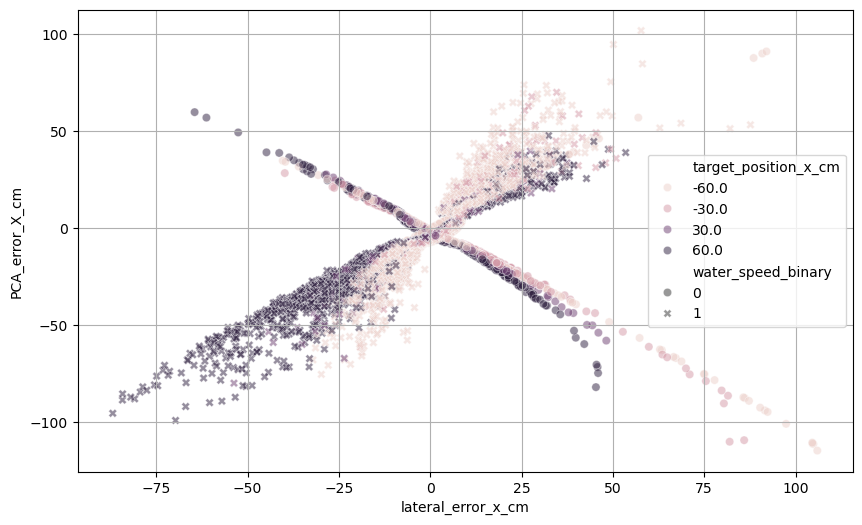

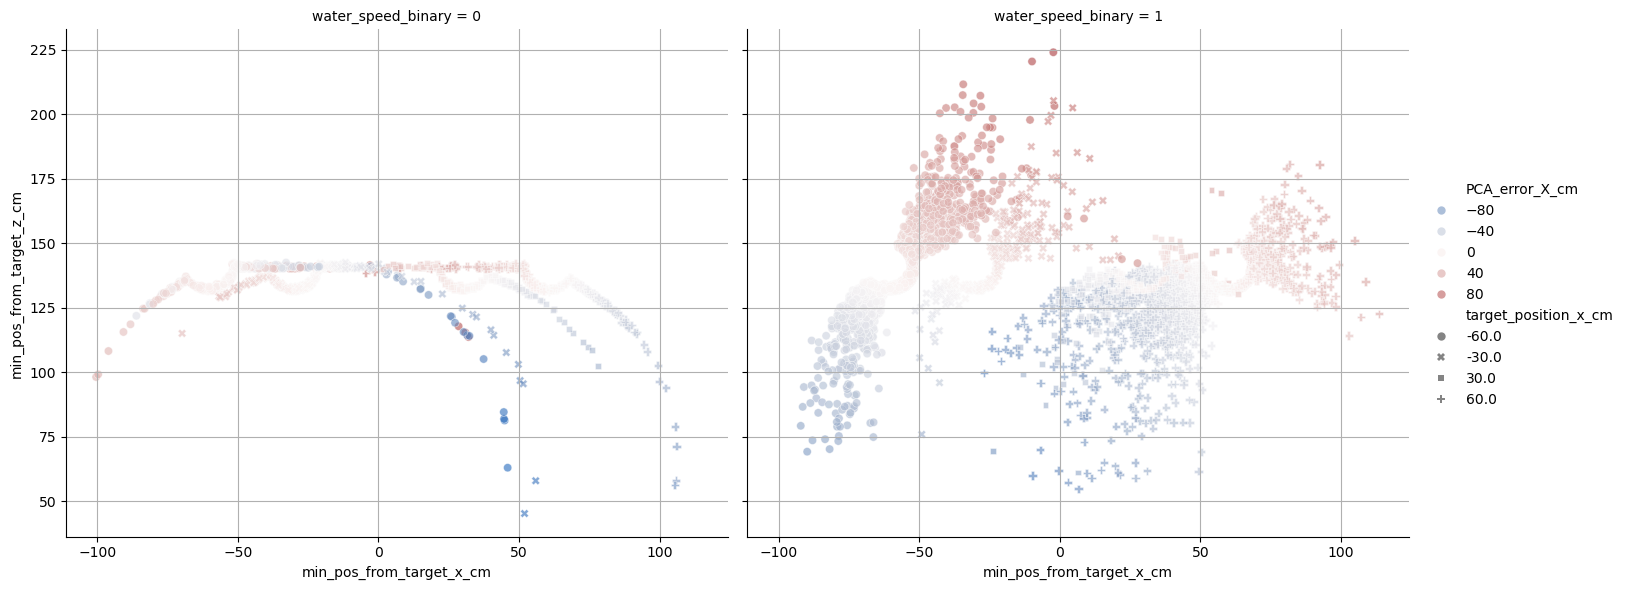

In [11]:
from src.PCA import compute_PCA_summary

PCA_table = compute_PCA_summary(df_small_filt,
            features = ['min_pos_from_target_x_cm','min_pos_from_target_z_cm'],
            group_cols = ['water_speed_m_s','set_order','target_position_x_cm'],
            water_col = 'water_speed_m_s',
            n_components=2
            )
PCA_table


# extract relevant columns
PCA_table_small = PCA_table.iloc[:, 0:9].copy()
PCA_table_small


# merge small summary table into raw df with trial-by-trial data
df_angles = df_small_filt.copy()

group_cols = ['water_speed_m_s','set_order','target_position_x_cm']

new_cols = ['pc_vector_1_angle','pc_vector_1_pca_center_x','pc_vector_1_pca_center_z','pc_vector_1_c_X','pc_vector_1_c_Z']

df_angles_v = df_angles.merge(PCA_table_small[group_cols + new_cols], how="left", on=group_cols)

from src.PCA import compute_PCA_error

PCA_error_df = compute_PCA_error(trial_df=df_angles_v,
                  pc_deg='pc_vector_1_angle',
                  target_x_col='target_position_x_cm',
                  target_z_col='target_position_z_cm',
                  features = ['min_pos_from_target_x_cm','min_pos_from_target_z_cm'],
                  water_col = 'water_speed_m_s'
                 )
PCA_error_df




# visualzation of correltaion between lateral error & diagonal error
plt.figure(figsize=(10,6))
sns.scatterplot(data=PCA_error_df, x='lateral_error_x_cm', y='PCA_error_X_cm', 
                hue='target_position_x_cm', style='water_speed_binary', alpha=0.5)
plt.grid(True)
plt.show()




# Visualization of diagonal error
g = sns.relplot(
    data=PCA_error_df, 
    x='min_pos_from_target_x_cm', 
    y='min_pos_from_target_z_cm',
    hue='PCA_error_X_cm', 
    style='target_position_x_cm',
    col='water_speed_binary',  
    palette='vlag',            
    alpha=0.6,
    kind='scatter',
    height=6,
    aspect=1.2
)

# Apply grid to all faceted subplots
for ax in g.axes.flat:
    ax.grid(True)

plt.show()

In [13]:
from src.baseline_correct import baseline_correct

df_bc = baseline_correct(data = PCA_error_df,
                phase_col = 'phase',
                baseline_string='baseline',
                y_col='lateral_error_x_cm'
                )
df_bc

BASELINE: (606, 41)


C:\Users\jacob\water_current_MA\src\baseline_correct.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_baseline = df_filtered.groupby(grouping_vars)[y_col].mean().reset_index()


Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


In [ ]:
### SAVE PCA OUPUT DF

In [15]:

# Extract and join unique experiment strings
exp_tags = "_".join(df_bc['experiment'].unique().astype(str))

# Extract unique water speeds, rounded to prevent floating point noise
speeds = df_bc['water_speed_m_s'].unique()
speed_tags = "_".join([str(round(s, 1)).replace('-', 'neg').replace('.', '_') for s in np.sort(speeds)])

# construct the combined filename
file_name = f"PCA_error_{exp_tags}_speed_{speed_tags}.csv"
file_path = f"..\\data\\{file_name}"

df_bc.to_csv(file_path, index=False)
print(f"Saved: {file_path}")

Saved: ..\data\PCA_error_TD_2.0M_spatial_generalization_TU_2.0M_spatial_generalization_speed_neg2_0_0_0.csv


In [17]:
df_bc

Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


In [19]:
from src.early_late_exposure import early_late_phase

df_tmp = df_bc.copy()

early_late_phase_df = early_late_phase(df_tmp,
                                       group_cols=['ppid_full'],
                                       phase_col='phase',
                                       phases_to_keep=['training_1','training_2'],
                                       trial_col='phase_target_trial_num', 
                                       n_trials=4
                                      ).copy()

# Extract and join unique experiment strings
exp_tags = "_".join(early_late_phase_df['experiment'].unique().astype(str))

# Extract unique water speeds, rounded to prevent floating point noise
speeds = early_late_phase_df['water_speed_m_s'].unique()
speed_tags = "_".join([str(round(s, 1)).replace('-', 'neg').replace('.', '_') for s in np.sort(speeds)])

# construct the combined filename
file_name = f"early_late_phase_PCA_error_{exp_tags}_speed_{speed_tags}.csv"
file_path = f"..\\data\\{file_name}"

early_late_phase_df.to_csv(file_path, index=False)
print(f"Saved: {file_path}")

Saved: ..\data\early_late_phase_PCA_error_TD_2.0M_spatial_generalization_TU_2.0M_spatial_generalization_speed_neg2_0.csv


C:\Users\jacob\water_current_MA\src\early_late_exposure.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_max = df.groupby(group_cols + [phase_col])[trial_col].transform('max')


In [21]:
early_late_phase_df

Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False t

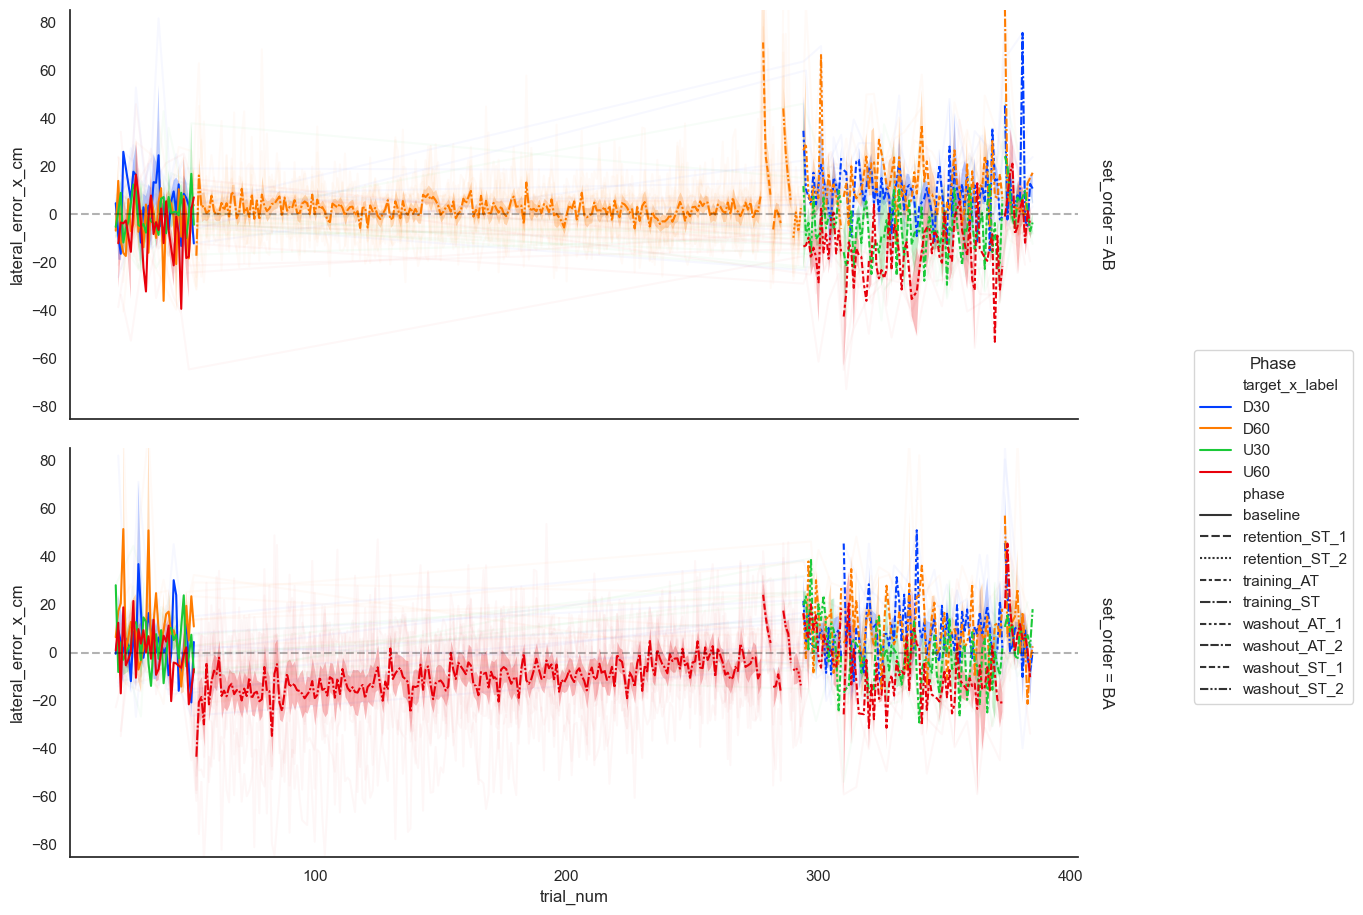

In [57]:
from src.plotting import plot_exposure_trials


plot_exposure_trials(PCA_error_df, 
                     col_col=None,
                     row_col='set_order',
                     cond_col='phase',
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'PCA_error_X_cm', 
                     x_col='trial_num',
                     context='poster', 
                     font_scale=3,
                     marker_size=0,
                     estimator='mean',
                     y_lim=(-85,85),
                     show_zero_line=True
                    )

C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False t

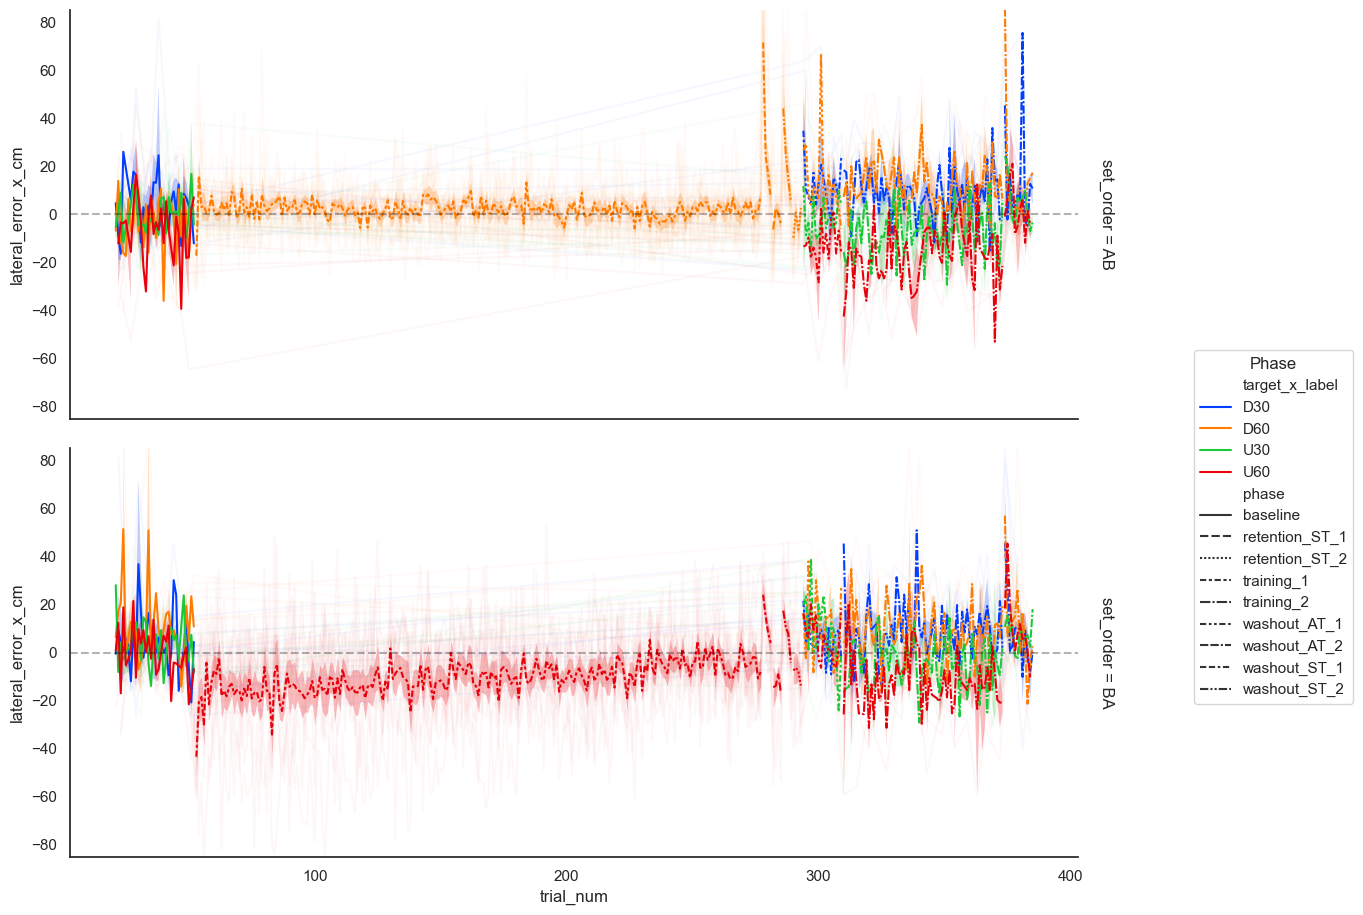

In [109]:
from src.plotting import plot_exposure_trials


plot_exposure_trials(PCA_error_df, 
                     col_col=None,
                     row_col='set_order',
                     cond_col='phase',
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'lateral_error_x_cm', 
                     x_col='trial_num',
                     context='poster', 
                     font_scale=3,
                     marker_size=0,
                     estimator='mean',
                     y_lim=(-85,85),
                     show_zero_line=True
                    )

C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False t

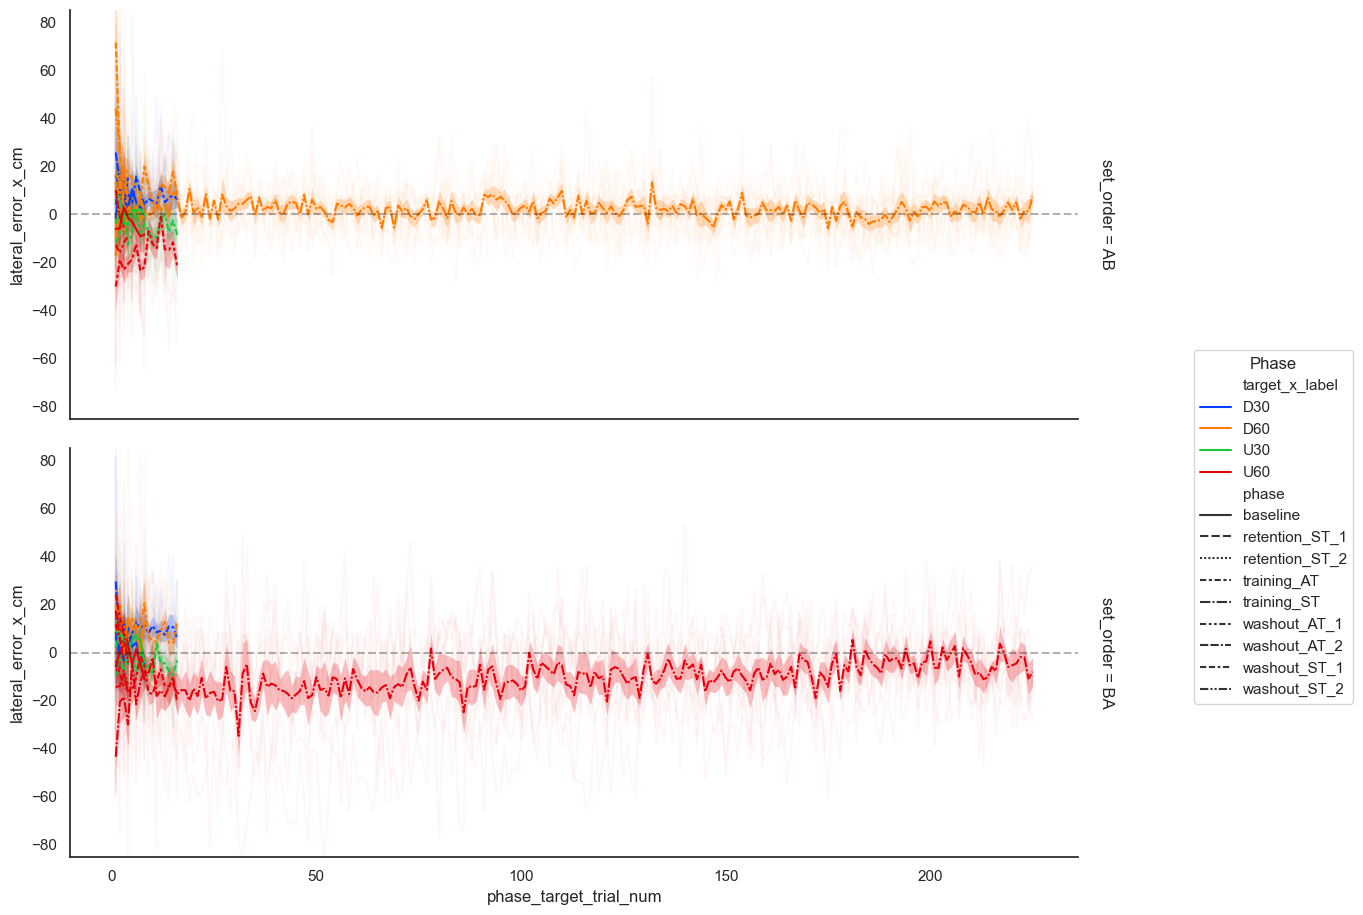

In [55]:
from src.plotting import plot_exposure_trials


plot_exposure_trials(PCA_error_df, 
                     col_col=None,
                     row_col='set_order',
                     cond_col='phase',
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'lateral_error_x_cm', 
                     x_col='phase_target_trial_num',
                     context='poster', 
                     font_scale=3,
                     marker_size=0,
                     estimator='mean',
                     y_lim=(-85,85),
                     show_zero_line=True
                    )

In [61]:
len(PCA_error_df['trial_num'])

6897

C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\axisgrid.py:854: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  func(*plot_args, **plot_kwargs)
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\axisgrid.py:854: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  func(*plot_args, **plot_kwargs)
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\axisgrid.py:854: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  func(*plot_args, **plot_kwargs)
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\axisgrid.py:854: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  func(*plot_args, **

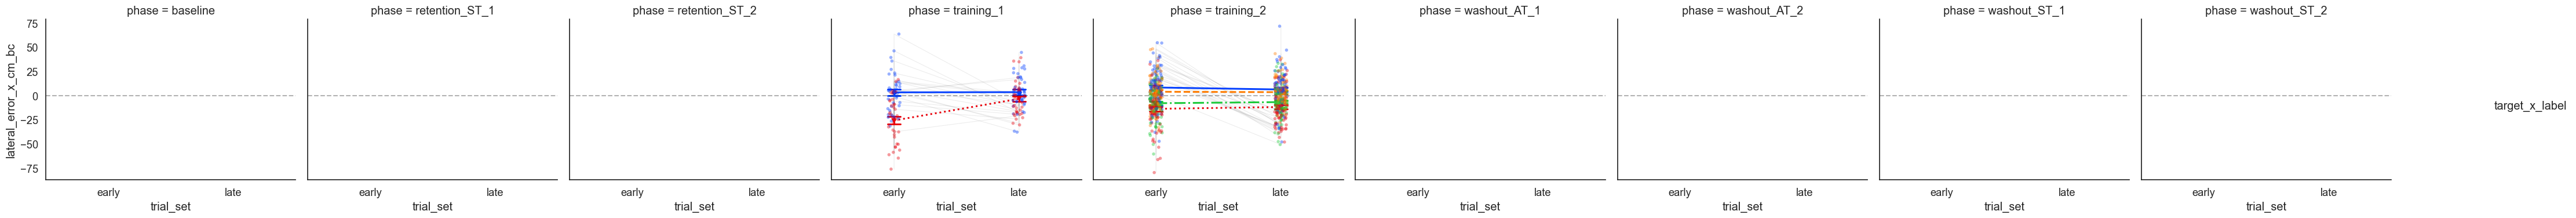

In [113]:

from src.plotting import plot_early_late_exposure


plot_early_late_exposure(early_late_phase_df,
                            cond_col='target_x_label', 
                            ppid_col='ppid_full',
                            y_col='lateral_error_x_cm_bc',
                            x_col='trial_set',
                            line_col ='set_order',
                            facet_row = None,
                            facet_col = 'phase',
                             show_zero_line=True)
#plot_early_late_exposure(early_late_10_means_dev)
#plot_early_late_exposure(early_late_10_means_speed)

C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False t

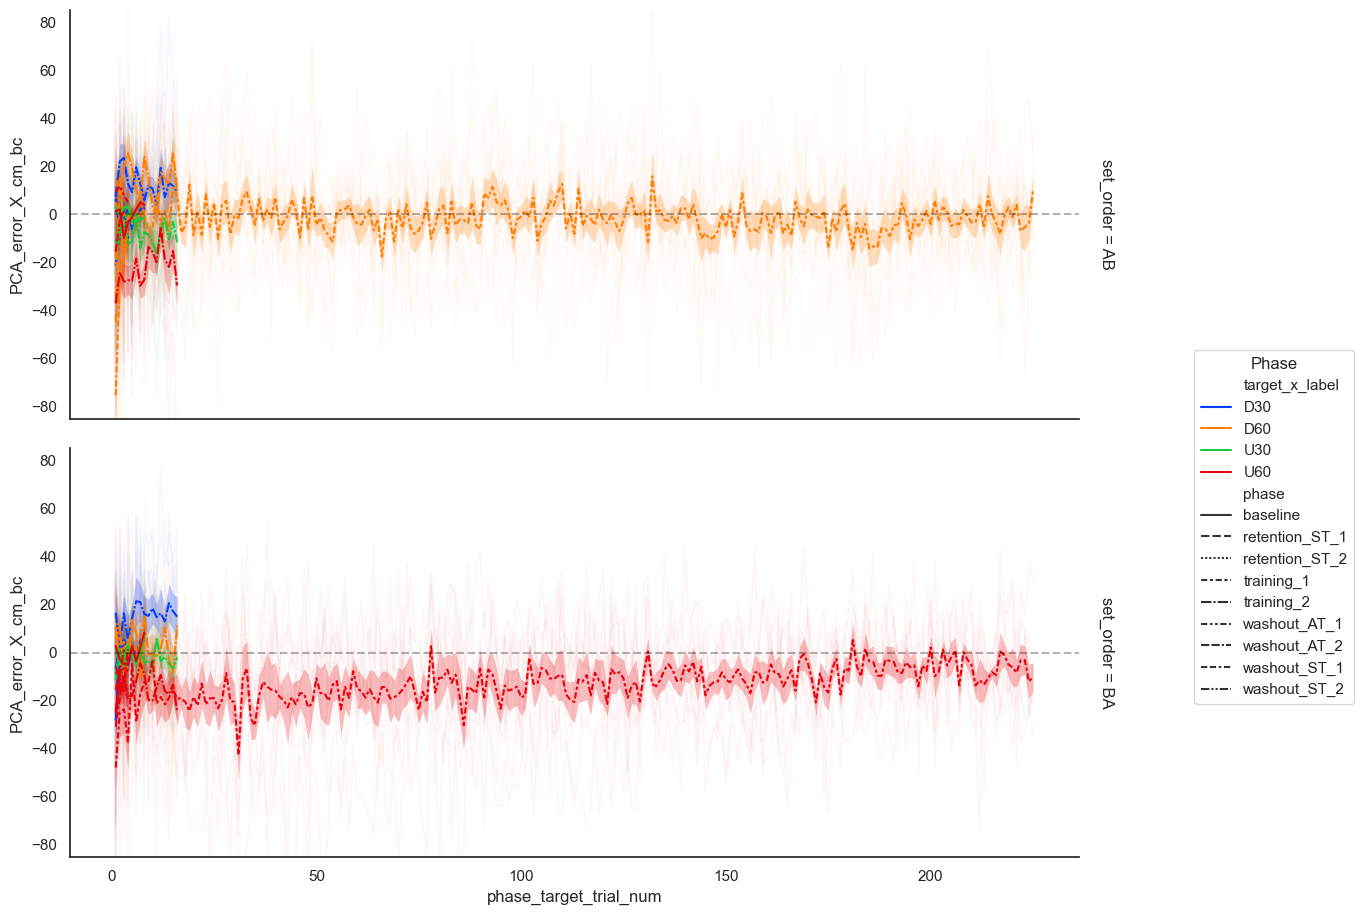

In [93]:
from src.plotting import plot_exposure_trials


plot_exposure_trials(df_bc, 
                     col_col=None,
                     row_col='set_order',
                     cond_col='phase',
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'PCA_error_X_cm_bc', 
                     x_col='phase_target_trial_num',
                     context='poster', 
                     font_scale=3,
                     marker_size=0,
                     estimator='mean',
                     y_lim=(-85,85),
                     show_zero_line=True
                    )